In [1]:
from qiskit import QuantumRegister, QuantumCircuit, AncillaRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeAlgiers

## **Quantum Ripple Carry Adder**

In [ ]:
a,b = map(int,input("Enter the two input values: ").split())


def decimal_to_binary(in_1, in_2):
    a,b = bin(in_1)[2:], bin(in_2)[2:]
    return a,b

def binary_to_decimal(in_1, in_2):
    a = int(in_1, 2)
    b = int(in_2, 2)
    return a, b

def sum(a,b,c_in):
    qc = QuantumCircuit(3)
    qc.cx(a,b)
    qc.cx(b,c_in)

def carry(a,b,c_in,c_out):
    qc = QuantumCircuit(4)
    qc.ccx(a,b,c_out)
    qc.cx(a,b)
    qc.ccx(c_in,b,c_out)
    
def inverse_carry(a,b,c_in,c_out):
    qc = QuantumCircuit(4)
    qc.ccx(c_in,b,c_out)
    qc.cx(a,b)
    qc.ccx(a,b,c_out)


bin_1, bin_2 = decimal_to_binary(a,b)


In [ ]:

print(bin_1, bin_2)

10 11


## **Quantum Full Adder**

In [2]:
q_in = QuantumRegister(3, name = "input")
q_anc = AncillaRegister(3, name= "ancilla")
q_out = QuantumRegister(2, name = "output")
c_reg = ClassicalRegister(2,"result")

qc = QuantumCircuit(q_in, q_anc, q_out, c_reg)

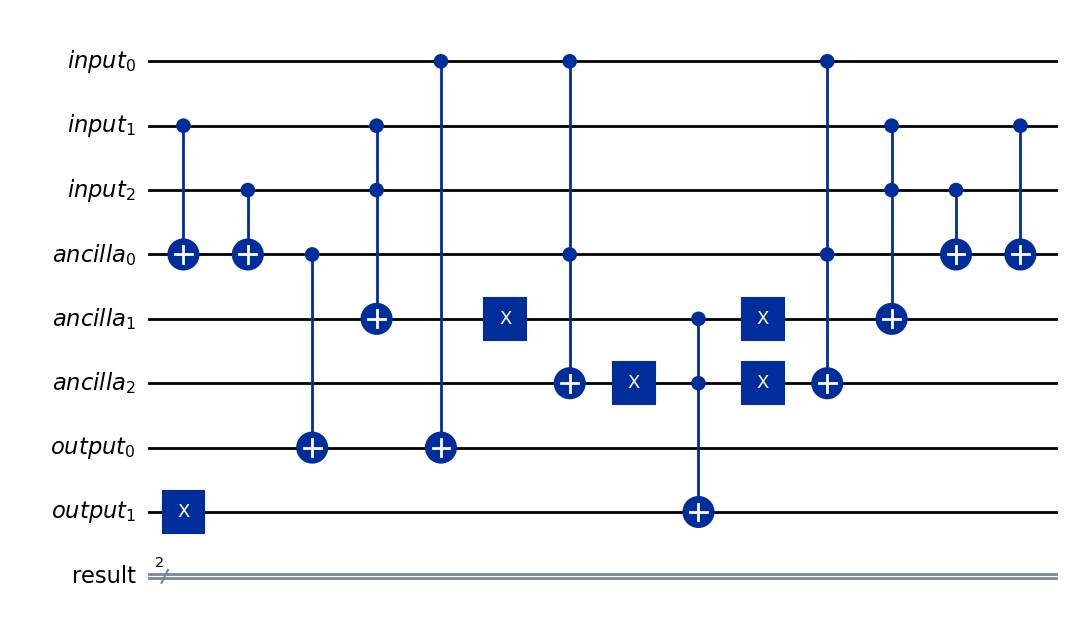

In [3]:
# qc.x(q_in[1]) we can change the input by initializing the qubit to 1
# qc.x(q_in[2])

qc.cx(q_in[1],q_anc[0])
qc.cx(q_in[2],q_anc[0])

qc.cx(q_anc[0],q_out[0])
qc.cx(q_in[0],q_out[0])

qc.ccx(q_in[1],q_in[2],q_anc[1])
qc.ccx(q_in[0],q_anc[0],q_anc[2])

qc.x(q_out[1])
qc.x([q_anc[1],q_anc[2]])
qc.ccx(q_anc[1],q_anc[2],q_out[1])
qc.x([q_anc[1],q_anc[2]])

qc.ccx(q_in[0], q_anc[0], q_anc[2])   
qc.ccx(q_in[1], q_in[2], q_anc[1])    
qc.cx(q_in[2], q_anc[0])               
qc.cx(q_in[1], q_anc[0])   

qc.draw('mpl')

In [4]:
qc.measure(q_out[0],c_reg[0])
qc.measure(q_out[1],c_reg[1])

sim = AerSimulator()
transpiled_qc = transpile(qc, sim)
job = sim.run(transpiled_qc, shots = 1024)
counts = job.result().get_counts()
print(counts)  # for adding two bit 00 = 00, 01 = 01, 10 = 01, 11 = 01 || c_res[0] => Sum, c_res[1] => Cout


{'00': 1024}


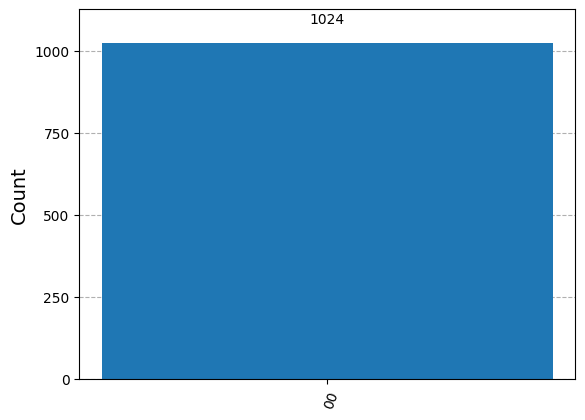

In [5]:
plot_histogram(counts)

In [7]:
fake_backend  = FakeAlgiers()
noise_model = NoiseModel.from_backend(fake_backend)
sim = AerSimulator(noise_model = noise_model)
transpiled_qc = transpile(qc,sim)
counts = sim.run(transpiled_qc).result().get_counts()
print(counts)

{'00': 952, '10': 58, '11': 1, '01': 13}


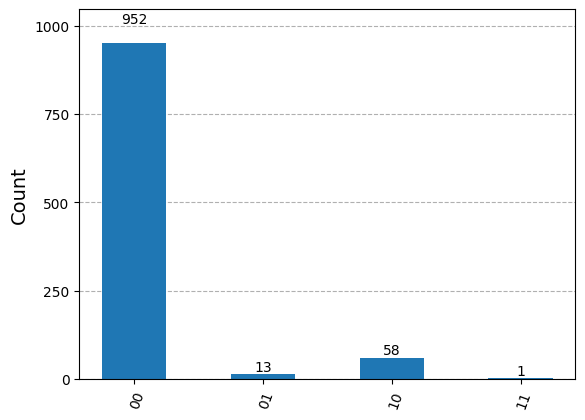

In [8]:
plot_histogram(counts)